In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('superstore_final_dataset.csv', encoding='latin-1')
print(f"Shape: {df.shape}")
df.head()

Shape: (9800, 18)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [3]:
print(df.columns.tolist())

['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales']


In [4]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')
df['Ship_Date']  = pd.to_datetime(df['Ship_Date'], dayfirst=True, errors='coerce')
df.drop_duplicates(inplace=True)
df.dropna(subset=['Order_Date', 'Ship_Date'], inplace=True)
df['Year']          = df['Order_Date'].dt.year
df['Month']         = df['Order_Date'].dt.month
df['Quarter']       = df['Order_Date'].dt.quarter
df['Days_to_Ship']  = (df['Ship_Date'] - df['Order_Date']).dt.days
print("\nCleaning done! Shape:", df.shape)
print(df.head(2))


Cleaning done! Shape: (9800, 22)
   Row_ID        Order_ID Order_Date  Ship_Date     Ship_Mode Customer_ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11  Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11  Second Class    CG-12520   

  Customer_Name   Segment        Country       City  ... Region  \
0   Claire Gute  Consumer  United States  Henderson  ...  South   
1   Claire Gute  Consumer  United States  Henderson  ...  South   

        Product_ID   Category Sub_Category  \
0  FUR-BO-10001798  Furniture    Bookcases   
1  FUR-CH-10000454  Furniture       Chairs   

                                        Product_Name   Sales  Year  Month  \
0                  Bush Somerset Collection Bookcase  261.96  2017     11   
1  Hon Deluxe Fabric Upholstered Stacking Chairs,...  731.94  2017     11   

   Quarter  Days_to_Ship  
0        4             3  
1        4             3  

[2 rows x 22 columns]


In [5]:
total_revenue   = df['Sales'].sum()
avg_order_value = df.groupby('Order_ID')['Sales'].sum().mean()
n_orders        = df['Order_ID'].nunique()
orders_per_cat  = df.groupby('Category')['Sales'].sum()
print("=" * 40)
print(f"  Total Revenue    : ${total_revenue:,.2f}")
print(f"  Avg Order Value  : ${avg_order_value:,.2f}")
print(f"  Total Orders     : {n_orders:,}")
print(f"\n  Revenue by Category:")
print(orders_per_cat)
print("=" * 40)

  Total Revenue    : $2,261,536.78
  Avg Order Value  : $459.48
  Total Orders     : 4,922

  Revenue by Category:
Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


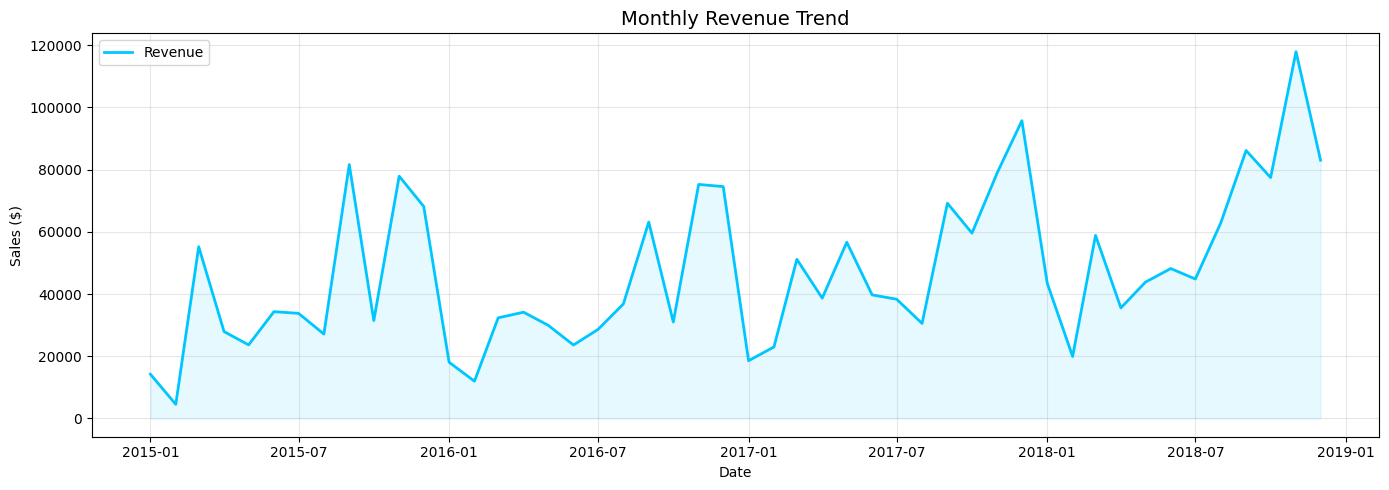

Chart saved!


In [6]:
monthly = df.groupby(df['Order_Date'].dt.to_period('M')).agg(Sales=('Sales','sum')).reset_index()
monthly['Order_Date'] = monthly['Order_Date'].dt.to_timestamp()
plt.figure(figsize=(14, 5))
plt.plot(monthly['Order_Date'], monthly['Sales'],color='#00C6FF', lw=2, label='Revenue')
plt.fill_between(monthly['Order_Date'], monthly['Sales'],alpha=0.1, color='#00C6FF')
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Sales ($)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('trend.png', dpi=150)
plt.show()
print("Chart saved!")

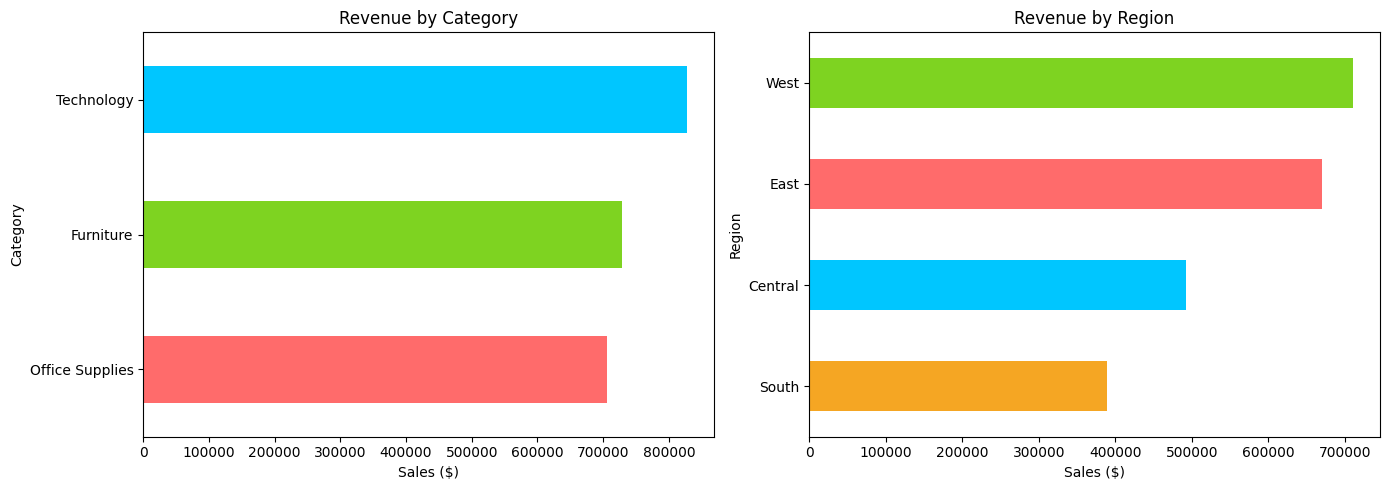

Chart saved!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_rev = df.groupby('Category')['Sales'].sum().sort_values()
cat_rev.plot(kind='barh', ax=axes[0],color=['#FF6B6B','#7ED321','#00C6FF'])
axes[0].set_title('Revenue by Category')
axes[0].set_xlabel('Sales ($)')
reg_rev = df.groupby('Region')['Sales'].sum().sort_values()
reg_rev.plot(kind='barh', ax=axes[1],color=['#F5A623','#00C6FF','#FF6B6B','#7ED321'])
axes[1].set_title('Revenue by Region')
axes[1].set_xlabel('Sales ($)')
plt.tight_layout()
plt.savefig('category_region.png', dpi=150)
plt.show()
print("Chart saved!")

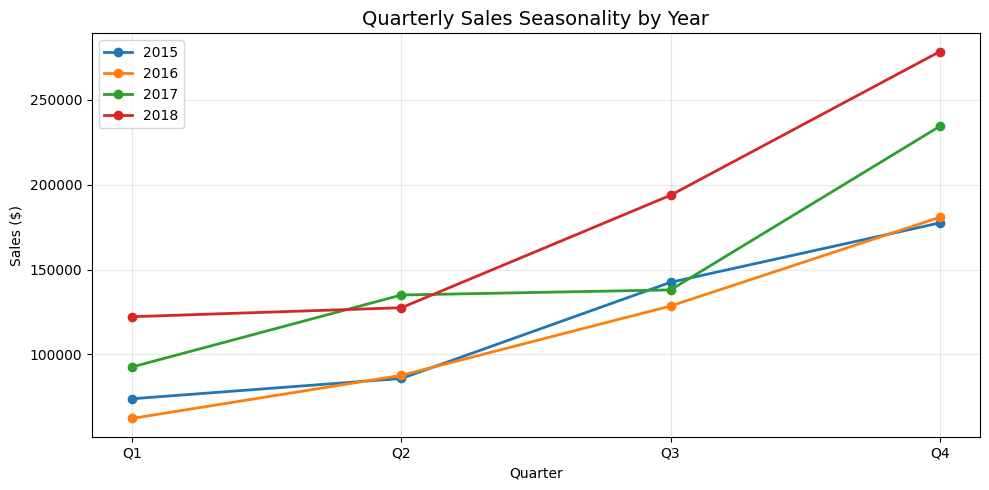

Chart saved!


In [8]:
quarterly = df.groupby(['Year','Quarter'])['Sales'].sum().reset_index()
plt.figure(figsize=(10, 5))
for year in sorted(quarterly['Year'].unique()):
    data = quarterly[quarterly['Year']==year]
    plt.plot([f"Q{q}" for q in data['Quarter']], 
             data['Sales'], marker='o', lw=2, label=str(year))
plt.title('Quarterly Sales Seasonality by Year', fontsize=14)
plt.xlabel('Quarter'); plt.ylabel('Sales ($)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('seasonality.png', dpi=150)
plt.show()
print("Chart saved!")

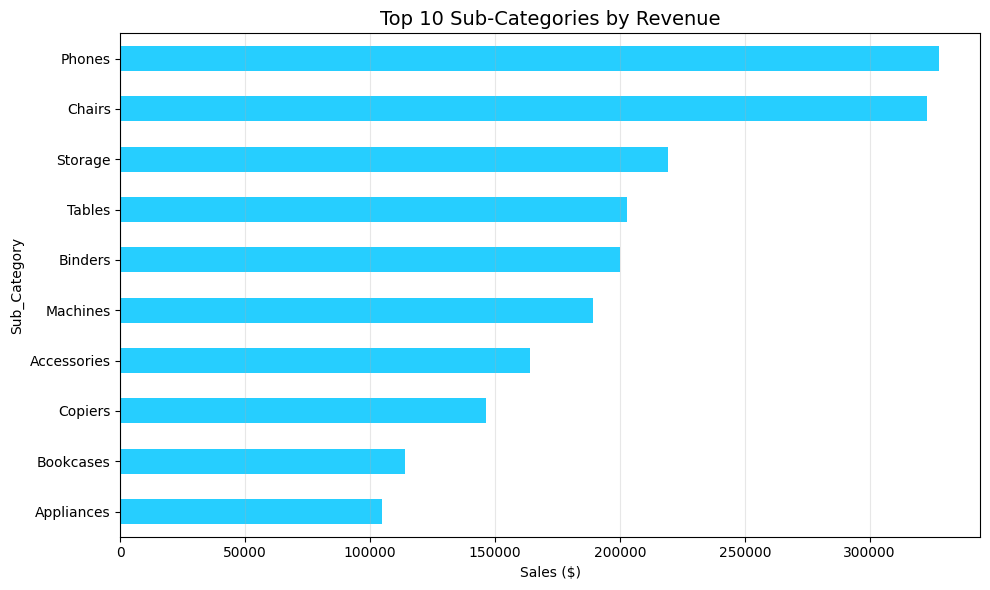

Chart saved!


In [9]:
top_sub = df.groupby('Sub_Category')['Sales'].sum().nlargest(10).sort_values()
plt.figure(figsize=(10, 6))
top_sub.plot(kind='barh', color='#00C6FF', alpha=0.85)
plt.title('Top 10 Sub-Categories by Revenue', fontsize=14)
plt.xlabel('Sales ($)'); plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('top_subcats.png', dpi=150)
plt.show()
print("Chart saved!")

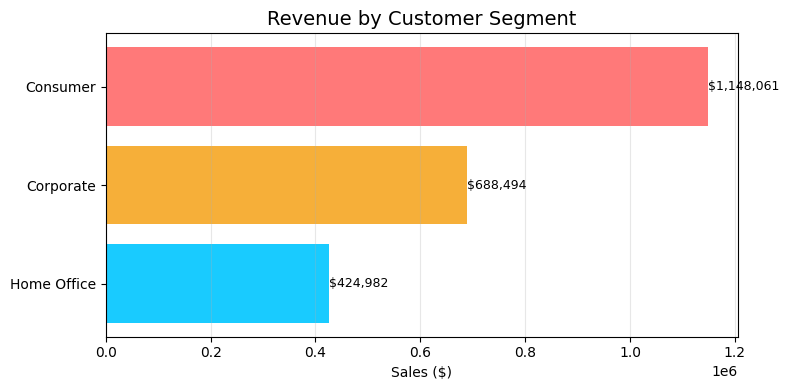

Chart saved!


In [10]:
seg = df.groupby('Segment')['Sales'].sum().sort_values()
plt.figure(figsize=(8, 4))
colors = ['#00C6FF','#F5A623','#FF6B6B']
bars = plt.barh(seg.index, seg.values, color=colors, alpha=0.9)
for bar in bars:
    plt.text(bar.get_width()+1000, bar.get_y()+bar.get_height()/2,
             f'${bar.get_width():,.0f}', va='center', fontsize=9)
plt.title('Revenue by Customer Segment', fontsize=14)
plt.xlabel('Sales ($)'); plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('segment.png', dpi=150)
plt.show()
print("Chart saved!")

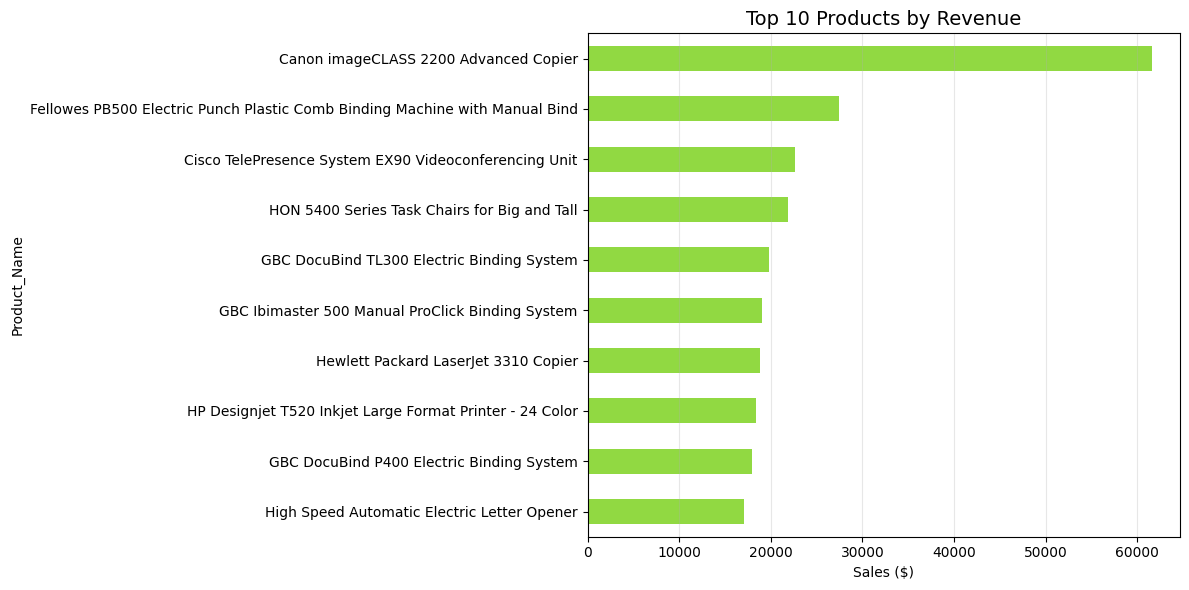

Chart saved!


In [11]:
top_products = df.groupby('Product_Name')['Sales'].sum().nlargest(10).sort_values()
plt.figure(figsize=(12, 6))
top_products.plot(kind='barh', color='#7ED321', alpha=0.85)
plt.title('Top 10 Products by Revenue', fontsize=14)
plt.xlabel('Sales ($)'); plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('top_products.png', dpi=150)
plt.show()
print("Chart saved!")

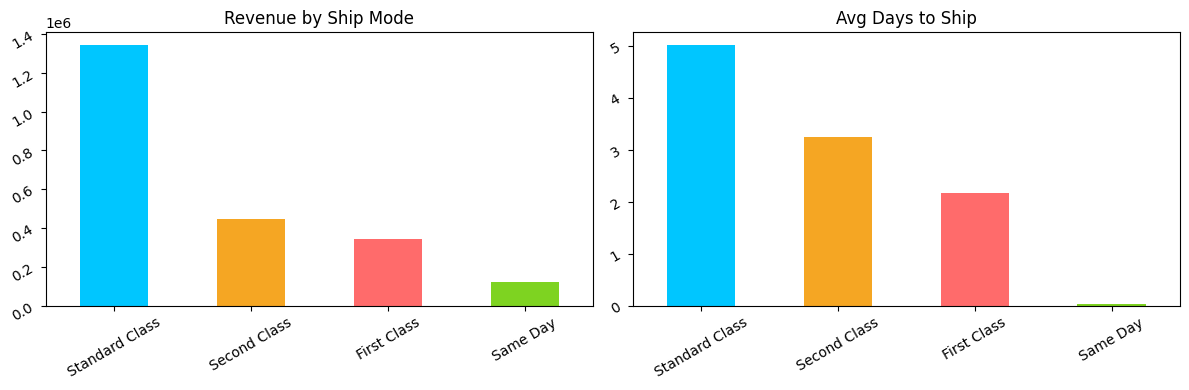

Chart saved!


In [12]:
ship = df.groupby('Ship_Mode').agg(
    Orders=('Order_ID','count'),
    Revenue=('Sales','sum'),
    AvgDays=('Days_to_Ship','mean')
).reset_index().sort_values('Revenue', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#00C6FF','#F5A623','#FF6B6B','#7ED321']
ship.plot(kind='bar', x='Ship_Mode', y='Revenue',ax=axes[0], color=colors, legend=False)
axes[0].set_title('Revenue by Ship Mode')
axes[0].set_xlabel(''); axes[0].tick_params(rotation=30)
ship.plot(kind='bar', x='Ship_Mode', y='AvgDays',ax=axes[1], color=colors, legend=False)
axes[1].set_title('Avg Days to Ship')
axes[1].set_xlabel(''); axes[1].tick_params(rotation=30)
plt.tight_layout()
plt.savefig('shipmode.png', dpi=150)
plt.show()
print("Chart saved!")

In [13]:
summary = df.groupby(['Category','Sub_Category']).agg(
    Revenue=('Sales','sum'),
    Orders=('Order_ID','count'),
    Avg_Sales=('Sales','mean')
).reset_index()
summary = summary.sort_values('Revenue', ascending=False)
summary.to_csv('summary_table.csv', index=False)
print("Summary exported!")
print(summary.head(10))

Summary exported!
           Category Sub_Category      Revenue  Orders    Avg_Sales
16       Technology       Phones  327782.4480     876   374.180877
1         Furniture       Chairs  322822.7310     607   531.833165
11  Office Supplies      Storage  219343.3920     832   263.633885
3         Furniture       Tables  202810.6280     314   645.893720
6   Office Supplies      Binders  200028.7850    1492   134.067550
15       Technology     Machines  189238.6310     115  1645.553313
13       Technology  Accessories  164186.7000     756   217.178175
14       Technology      Copiers  146248.0940      66  2215.880212
0         Furniture    Bookcases  113813.1987     226   503.598224
4   Office Supplies   Appliances  104618.4030     459   227.926804
